### ***PRACTICA 1***

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import imageio
from io import BytesIO
import os
from IPython import display
import tempfile

In [21]:
#Defining fucntions that will be used 
def y_of_x(x: np.array):
    """Evaluates the function $y = (x^2 - 4)^3 + 2$ at point x provided as input arguments."""
    y = (x**2 - 4)**3 + 2
    return y

def y_of_x_from_compositions(x: np.array):
    """Evaluates the function $y = (x^2 - 4)^3 + 2$ at point x provided as input arguments.

    Using the following composition of functions.

    $$
    \begin{split}
    \text{...}
    \end{split}
    $$
    
    """
    t = x
    u = t**2
    z = u - 4
    y = z**3 + 2
    return y

def partial_y_partial_x(x : np.array):
    dy_dx = 6*x*(x**2 - 4)**2
    
    return dy_dx

def partial_y_partial_x_chain_rule(x : np.array):
    """Evaluates the derivative of $y = (x^2 - 4)^3 + 2$ at point x provided as input arguments, using chain rule.
    
    To do so we use composition:

    $$
    \begin{split}
    t = \text{...} \\
    u = \text{...} \\
    z = \text{...} \\
    y = \text{...}
    \end{split}
    $$

    using partial derivatives:

    $$
    \begin{split}
    \frac{\partial y}{\partial z} = \text{...}
    \frac{\partial z}{\partial u} = \text{...}
    \frac{\partial u}{\partial t} = \text{...}
    \frac{\partial t}{\partial x} = \text{...}
    \end{split}
    $$
    """
    # we need to go through the function computation, (i.e forward operation) to obtain derivative using chain rule, so that 
    # we can replace u in the derivative.
    t = x
    u = t**2
    z = u - 4
    y = z**3 + 2
    
    dt_dx = 1
    du_dt = 2*t
    dz_du = 1
    dy_dz = 3*z**2

    
    dy_dx = dy_dz * dz_du * du_dt * dt_dx
    
    return dy_dx


<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:41: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:41: SyntaxWarning: invalid escape sequence '\e'
C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\1996552027.py:15: SyntaxWarning: invalid escape sequence '\e'
  \end{split}
C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\1996552027.py:41: SyntaxWarning: invalid escape sequence '\e'
  \end{split}


Text(0.5, 0.98, 'Using Chain Rule')

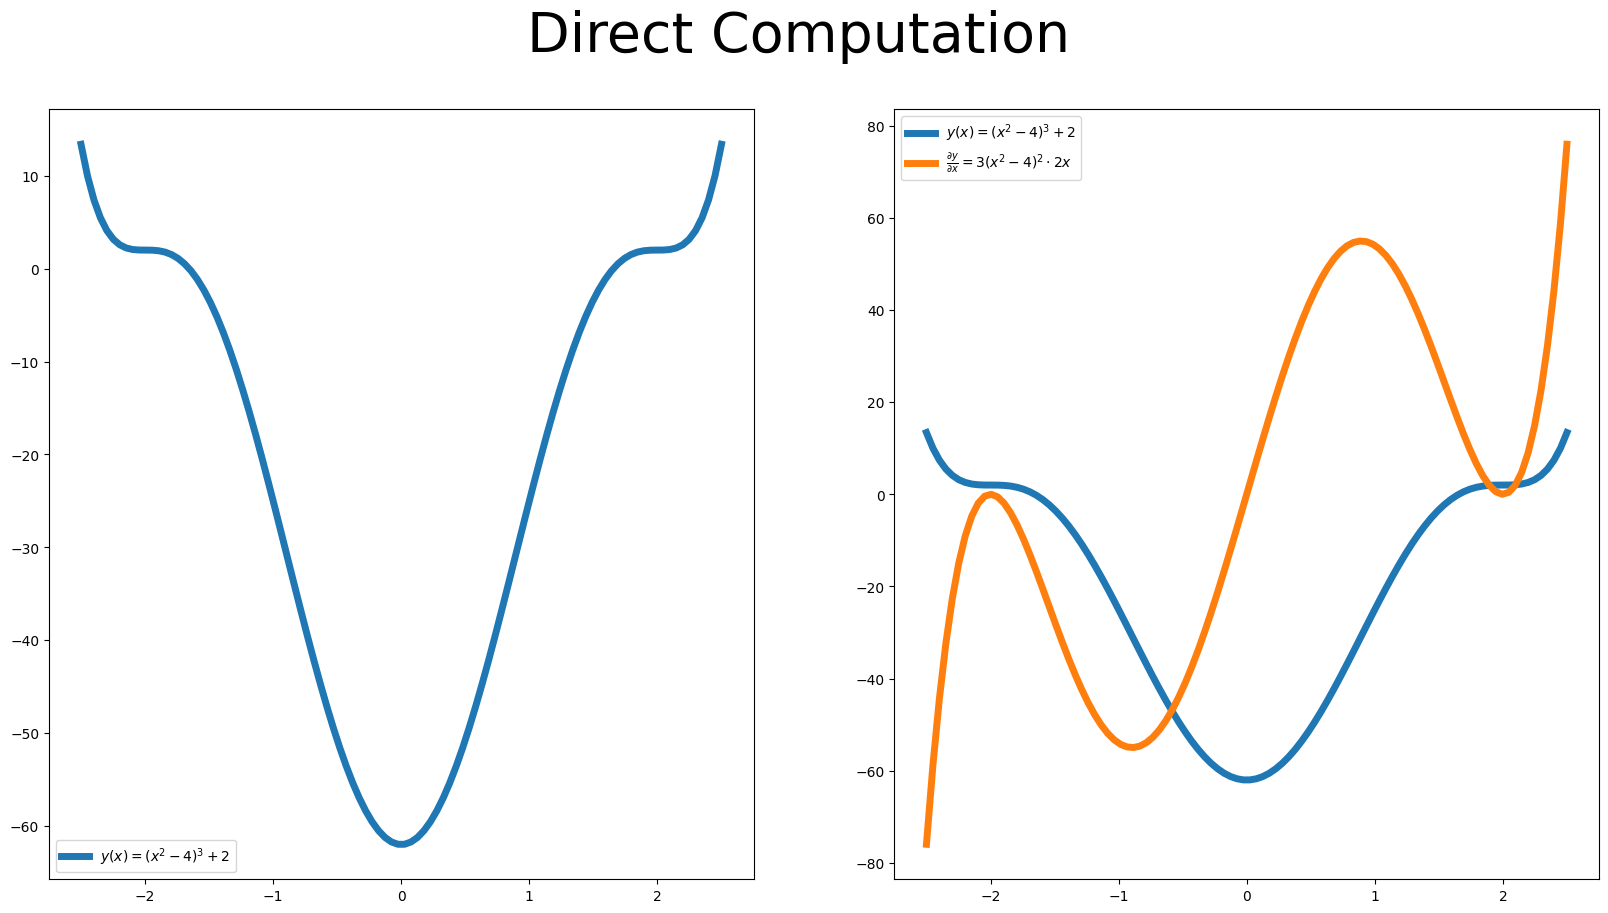

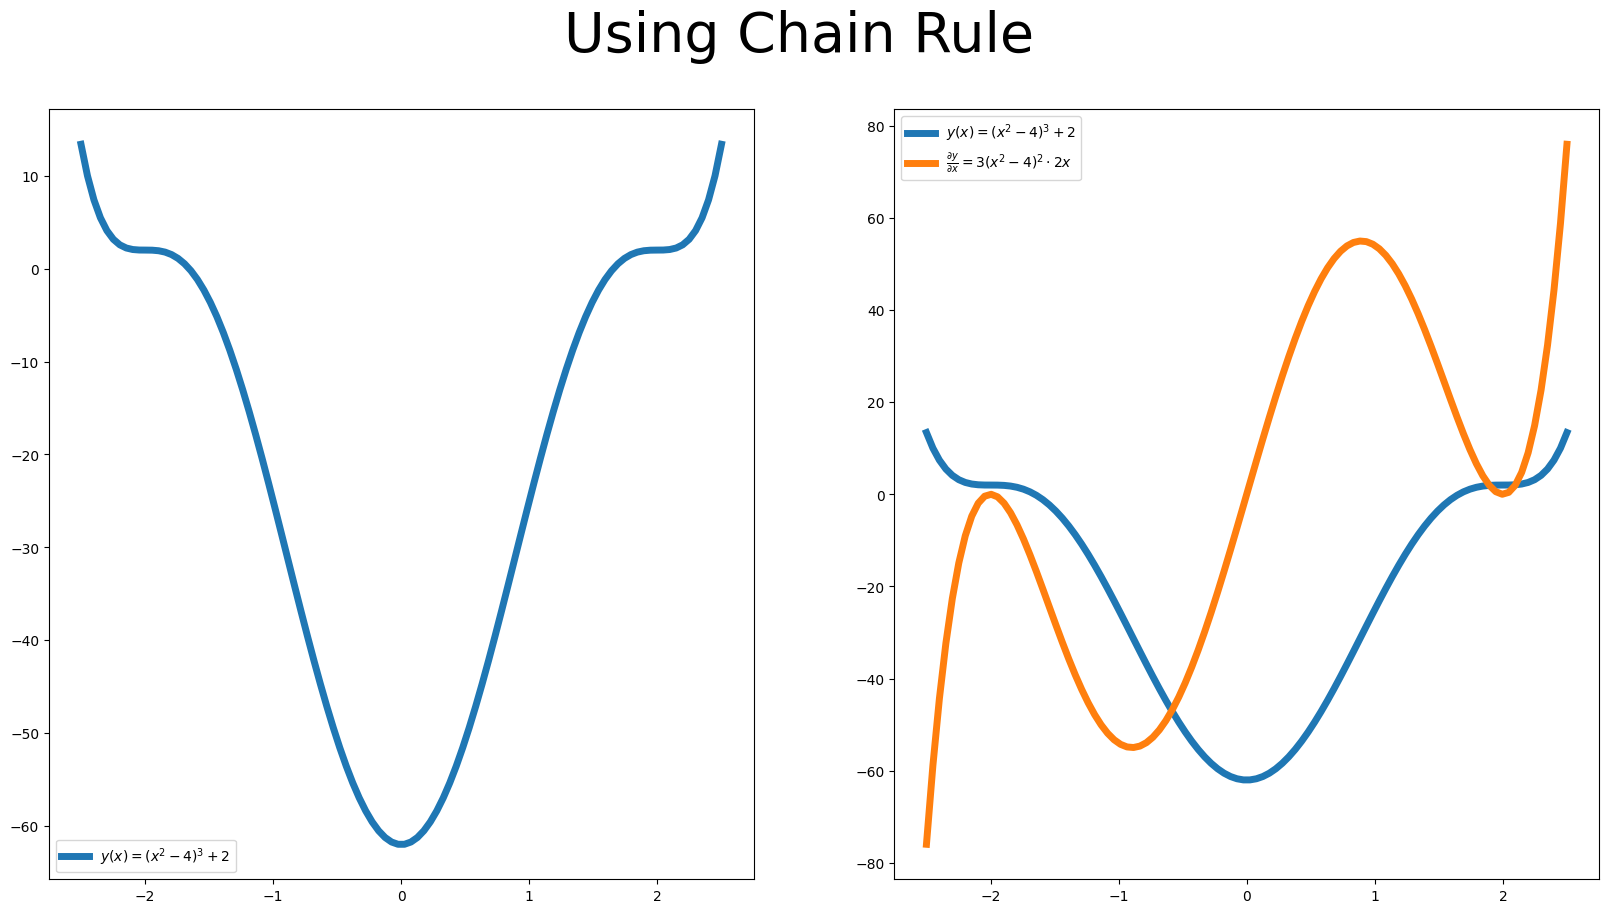

In [22]:
## range over which we want to plot the function
x_min = -2.5
x_max = 2.5
N_points = 100

x = np.linspace(x_min, x_max, N_points)

## Using direct computation
y = y_of_x(x)
dy_dx = partial_y_partial_x(x)

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10))

ax1.plot(x, y, label = '$y(x) = (x^2 - 4)^3 + 2$', linewidth = 5)
ax2.plot(x, y, label = '$y(x) = (x^2 - 4)^3 + 2$', linewidth = 5)
ax2.plot(x, dy_dx, label = r'$\frac{\partial y}{\partial x} = 3(x^2 - 4)^2 \cdot 2x$', linewidth = 5)
ax1.legend()
ax2.legend()
plt.suptitle("Direct Computation", fontsize = 40)

## Using composition of functions and chain rule
y = y_of_x_from_compositions(x)
dy_dx = partial_y_partial_x_chain_rule(x)

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10))

ax1.plot(x, y, label = '$y(x) = (x^2 - 4)^3 + 2$', linewidth = 5)
ax2.plot(x, y, label = '$y(x) = (x^2 - 4)^3 + 2$', linewidth = 5)
ax2.plot(x, dy_dx, label = r'$\frac{\partial y}{\partial x} = 3(x^2 - 4)^2 \cdot 2x$', linewidth = 5)
ax1.legend()
ax2.legend()
plt.suptitle("Using Chain Rule", fontsize = 40)


Text(0.5, 0.98, 'Computation with Automatic Differentiation')

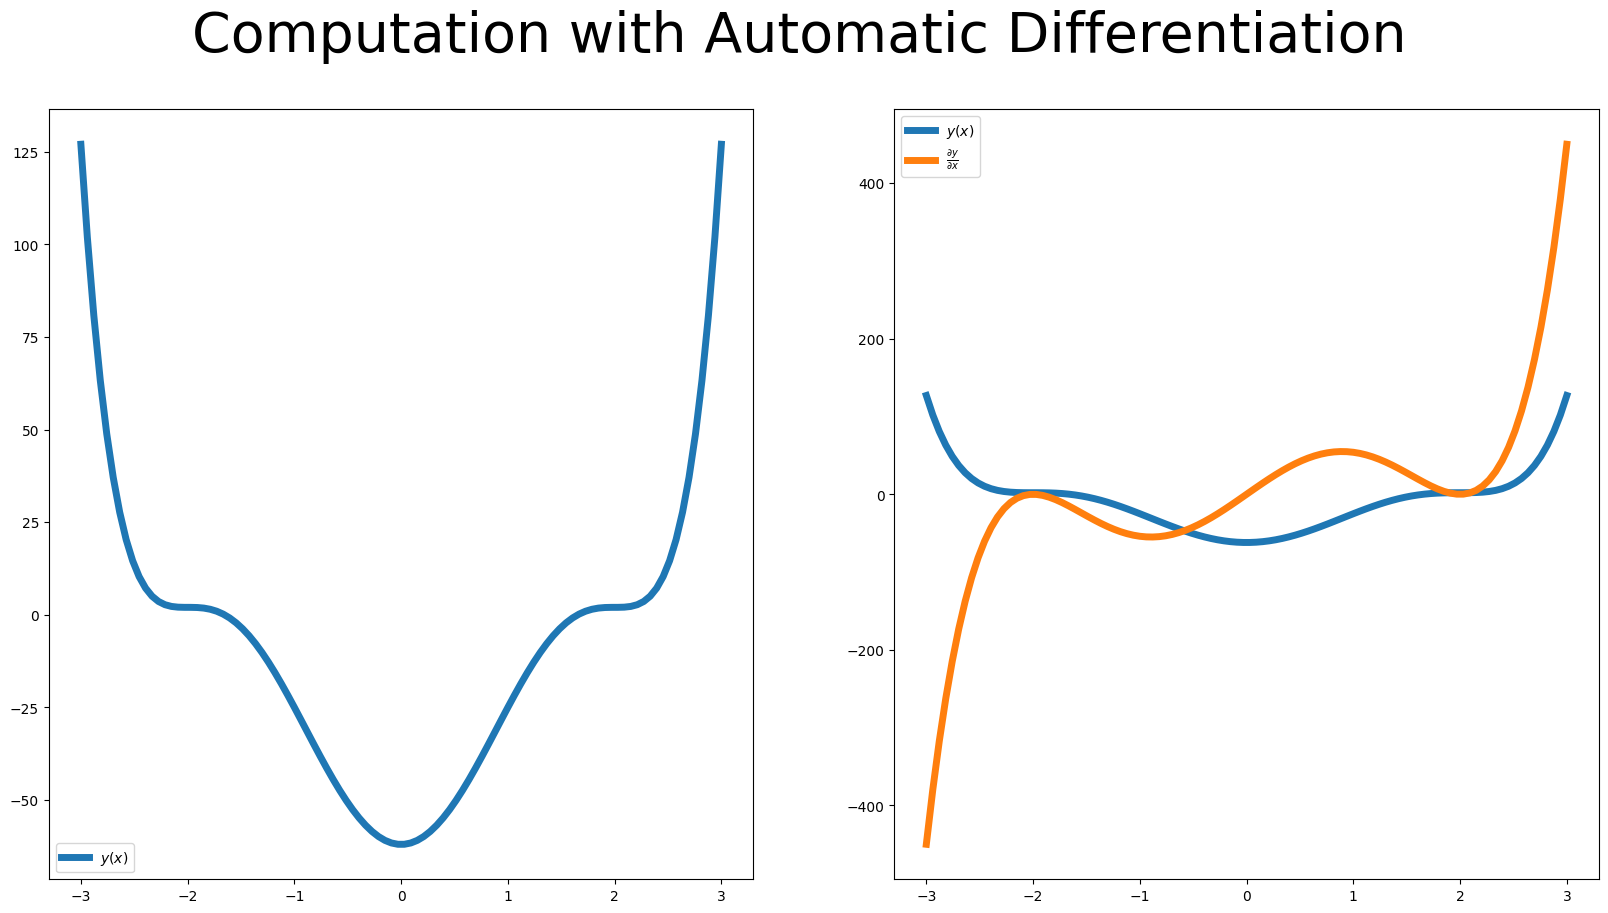

In [23]:
#Torch implementation
def y_of_x_torch(x : torch.tensor):
    """Evaluates the function $y = (x^2 - 4)^3 + 2$ at point x provided as input arguments."""
    y = (x**2 - 4)**3 + 2
    return y

## with pytorch we can create the associated gradient function by just specifying the computational_graph. This tell us
#  pytorch to provide a funciton that obtains the grad of y_of_x(x) wrt x. Forget about vmap and grad, they are advanced 
#  functions you wont use yet but are useful to me to show what I want to show.
dy_dx_fun = torch.func.vmap( torch.func.grad(y_of_x_torch, argnums = 0) )

## range over which we want to plot the function
x_min = -3
x_max = 3
N_points = 100

x = np.linspace(x_min, x_max, N_points)

## conver to torch tensor.
x = torch.tensor(x, dtype=torch.float32)
## Tell pytorch this tensor requires grad so gradient is saved
x.requires_grad = True

## Forward operation: compute y(x)
y = y_of_x_torch(x)

## Backward operation: evaluate the gradient function
dy_dx = dy_dx_fun(x)

## Convert back to numpy vectors. We use detach since vectors require gradients
x = x.detach().numpy()
y = y.detach().numpy()
dy_dx = dy_dx.detach().numpy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10))

ax1.plot(x, y, label = '$y(x)$', linewidth = 5)
ax2.plot(x, y, label = '$y(x)$', linewidth = 5)
ax2.plot(x, dy_dx, label = r'$\frac{\partial y}{\partial x}$', linewidth = 5)
ax1.legend()
ax2.legend()
plt.suptitle("Computation with Automatic Differentiation", fontsize = 40)

In [24]:

## torch tensor point at which we want the gradient
x = torch.tensor([1.0], dtype=torch.float32, requires_grad = True)

## evaluate the derivative at that point using torch function
dy_dx = dy_dx_fun(x)

## evaluate the derivative at that point using our numpy function

#.detach is used to disconnect the tensor from the computational graph
#.numpy() is used to convert the tensor to a numpy array

dy_dx_np = partial_y_partial_x(x.detach().numpy())


## evaluate the derivative at that point using our chain rule numpy function
dy_dx_np_cr = partial_y_partial_x_chain_rule(x.detach().numpy())

## ===========================================
## obtain the derivative at the point directly

# forward through computational graph in pytorch
y = y_of_x_torch(x)
# obtain derivatives wrt to all tensors that require gradient
y.backward()
# observe the gradient
print('Gradient using the gradient function evaluated at a point ', dy_dx.detach().numpy())
print('Gradient using the gradient function using numpy grad function ', dy_dx_np)
print('Gradient using the gradient function using chain rule numpy grad function ', dy_dx_np_cr)
print('Gradient of a tensor using backward on computational graph ', x.grad.detach().numpy())

Gradient using the gradient function evaluated at a point  [54.]
Gradient using the gradient function using numpy grad function  [54.]
Gradient using the gradient function using chain rule numpy grad function  [54.]
Gradient of a tensor using backward on computational graph  [54.]


**DERIVATIVES W.R.T MULTIPLE VARIABLES**

In [25]:
## First case: Compute derivative wrt x and z
x = torch.tensor([2.], requires_grad = True)
z = torch.tensor([3.], requires_grad = True)

# forward: compute y from inputs x and z
u = 2*x +z
y = (3-u)**2 + z

## Backward: compute gradient wrt tensors that require grad. 
#  u also requires grad since it comes from operations involving tensor that do require grad (x and z).
y.backward()

print('u requires grad: ', u.requires_grad)
print('Gradient of y wrt x: ', x.grad)
print('Gradient of y wrt z: ', z.grad)

## =====================================
## Second case: Compute derivative wrt x
x = torch.tensor([2.], requires_grad = True)
z = torch.tensor([3.], requires_grad = False)

# forward: compute y from inputs x and z
u = 2*x +z
y = (3-u)**2 + z

## Backward: compute gradient wrt tensors that require grad. 
#  u also requires grad since it comes from operations involving tensor that do require grad (x and z).
y.backward()

print('u requires grad: ', u.requires_grad)
print('Gradient of y wrt x: ', x.grad)
print('Gradient of y wrt z: ', z.grad)

## =====================================
## Third case: Compute derivative wrt z
x = torch.tensor([2.], requires_grad = False)
z = torch.tensor([3.], requires_grad = True)

# forward: compute y from inputs x and z
u = 2*x +z
y = (3-u)**2 + z

## Backward: compute gradient wrt tensors that require grad. 
#  u also requires grad since it comes from operations involving tensor that do require grad (x and z).
y.backward()

print('u requires grad: ', u.requires_grad)
print('Gradient of y wrt x: ', x.grad)
print('Gradient of y wrt z: ', z.grad)

u requires grad:  True
Gradient of y wrt x:  tensor([16.])
Gradient of y wrt z:  tensor([9.])
u requires grad:  True
Gradient of y wrt x:  tensor([16.])
Gradient of y wrt z:  None
u requires grad:  True
Gradient of y wrt x:  None
Gradient of y wrt z:  tensor([9.])


**1. Regresion  f:R→R**

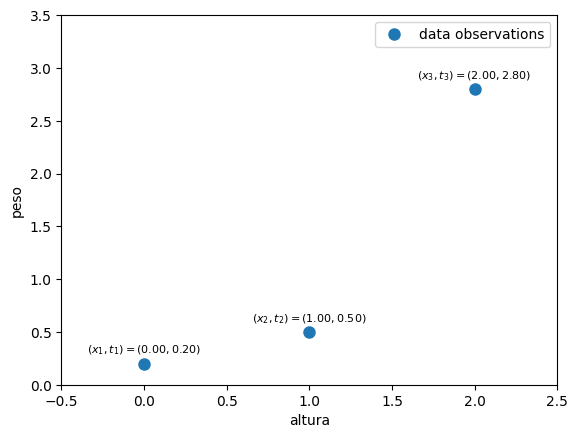

In [26]:
#1.1 We are going to define the point we are going to study, they should be wrapped to tensors

#Plotting the data

# input to our model. Represents time in seconds
x_data =  torch.from_numpy(np.array([0,1,2]).reshape(3,1)).float()
# outputs associated to each input. Represents cantidad de lluvia in mm^3
t_data = torch.from_numpy(np.array([0.2,0.5,2.8]).reshape(3,1)).float()

## display
plt.plot(x_data,t_data,'o', markersize = 8, label = 'data observations')
for i in range(len(x_data)):
    plt.text(x_data[i], t_data[i] + 0.1, f"$(x_{i+1},t_{i+1})=({float(x_data[i]):.2f},{float(t_data[i]):.2f})$", fontsize=8, ha="center")  # Etiqueta sobre el punto
plt.xlabel('altura')
plt.ylabel('peso')
plt.ylim([0,3.5])
plt.xlim([-0.5,2.5])
plt.legend()

In [27]:
#1.2 Initialization of parameters

w = torch.from_numpy(np.array([0.2])).float()
w.requires_grad = True

b = torch.from_numpy(np.array([0.8])).float()
b.requires_grad = True

parameters = [w,b] 

#1.3 Computational graph creation

def forward(x, parameters):
    for w, b in parameters:
        y = w*x + b
    return y

# 1.4 Loss function computation

def loss_function_square(t,y):
    L = sum((t-y)**2)
    return L

def loss_function_absolute(t,y):
    L = sum(abs(t-y))
    return L

def loss_funtion_square_torch(t,y):
    L = torch.sum((t-y)**2)  
    return L

def loss_funtion_absolute_torch(t,y):
    L = torch.sum(torch.abs(t-y))  
    return L


**1.5 IMPLEMENT GRADIENT DESCENT**

Right now we need to implement an iterative algorithm that implements gradient descent 

In [28]:
#1.5 Implement Gradient Descent

loss_type = 'sse'

if loss_type not in ["sse","sse_pytorch","abs","abs_pytorch"]:
    raise ValueError("Invalid loss type")

## create the plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))
x_range = torch.linspace(-1,3,20).view(20,1)

# Create temporary file for video creation
video_filename = os.path.join(tempfile.gettempdir(), "aux.mp4")

## video writer
writer = imageio.get_writer(video_filename, format="FFMPEG", mode="I", fps=1, codec="libx264")

## Learning algorithm
epochs = 50
lr = 0.1

# 1. Initialize the model
w = torch.from_numpy(np.array([0.2]).reshape(-1,1)).float()
w.requires_grad = True
b = torch.from_numpy(np.array([0.8]).reshape(-1,1)).float()
b.requires_grad = True

parameters = [(w,b)]
loss_acc = []
for e in range(epochs):
    
    # 2. Forward and loss computation
    y_data = forward(x_data, parameters)
    
    if loss_type == "sse":
        L = loss_function_square(y_data, t_data)
        
    elif loss_type == "abs":
        L = loss_function_absolute(y_data, t_data)
        
    elif loss_type == "sse_pytorch":
        L = loss_funtion_square_torch(y_data, t_data)
        
    elif loss_type == "abs_pytorch":
        L = loss_funtion_absolute_torch(y_data, t_data  )

    # 3. Backward
    L.backward()
    loss_acc.append(L.item())
    
    # 5 Parameter update
    for w,b in parameters:
        w.data = w.data - lr * w.grad
        b.data = b.data - lr * b.grad
        
    # 6 Zero grad
    w.grad.zero_()
    b.grad.zero_()
    
    ## Plotting
    ax1.cla()
    ax2.cla()
    
    with torch.no_grad():
        
        ax1.plot(x_data,t_data,'o',label = 'observations')
        ax1.plot(x_range,forward(x_range, parameters),label = 'model')
        ax1.set_xlabel('altura')
        ax1.set_ylabel('peso')
        ax1.set_ylim([0,3.5])
        ax1.set_xlim([-0.5,2.5])
        ax1.legend()
        
        ax2.plot(np.arange(0,e+1),loss_acc[:e+1])
        ax2.set_xlim([0,epochs])
        ax2.set_xlabel('epochs')
        ax2.set_ylabel('loss')
        ax2.set_title(f"{loss_type}")
    
    ## ========================
    ## save for video generation
    
    ## Cortesía de chatGPT (desde linea siguiente hasta el final de esta celda):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    
    buf.seek(0)
    frame = imageio.imread(buf) 
    writer.append_data(frame)  

writer.close() 
plt.close()

display.display(display.Video(data=video_filename, embed=True))
os.remove(video_filename)


C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\2968718385.py:88: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(buf)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


**2. Regression from  f:R→[0,1]**

We are going to repeat the processs using BCE and Brier score

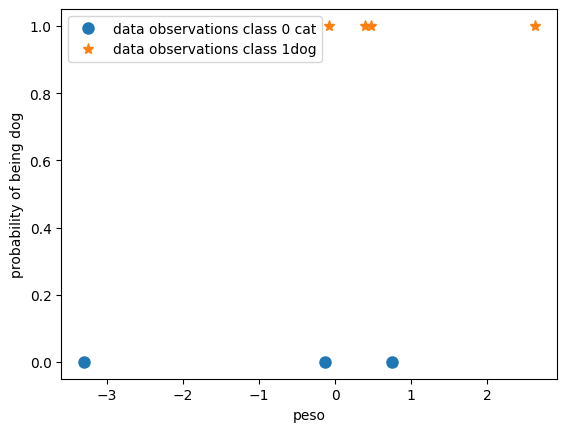

In [29]:
# 2.1 Wrapping the data to torch tensors

color_c0 = 'C0'
color_c1 = 'C1'

# input to our model. Represents time in seconds
x_data = torch.from_numpy(np.array([-0.13459237, -3.3015387, 0.74481176, 2.62434536, 0.38824359, 0.47182825, -0.07296862 ]).reshape(7,1)).float()
# outputs associated to each input. Represents cantidad de lluvia in mm^3
t_data = torch.from_numpy(np.array([0, 0,0,1,1,1,1]).reshape(7,1)).float()


## display
idx_class0 = t_data == 0
idx_class1 = t_data == 1
plt.plot(x_data[idx_class0],t_data[idx_class0],'o', color = color_c0, markersize = 8, label = r'data observations class 0 cat')
plt.plot(x_data[idx_class1],t_data[idx_class1],'*', color = color_c1,markersize = 8, label = r'data observations class 1dog')
plt.xlabel('peso')
plt.ylabel('probability of being dog')
plt.legend()

# 2.2 Initialization of parameters
w = torch.from_numpy(np.array([0.2])).float()
w.requires_grad = True
b = torch.from_numpy(np.array([0.8])).float()
b.requires_grad = True
parameters = [(w,b)]

**2.3 - 2.4  Computational graph creation and Loss Function computation**

In [30]:
def forward(x, parameters, apply_sigmoid = False):
    for w, b in parameters:
        z = w*x + b
    if apply_sigmoid:
        y = 1/(1+ torch.exp(-z))
    else:
        y = z
    return y

def loss_function_brier(t,y):
    L = torch.mean((t-y)**2)
    return L

def loss_function_bce(t,y):
    L = -torch.mean(t*torch.log(y) + (1-t)*torch.log(1-y))
    #L = torch.nn.BCELoss()(y,t)
    return L

#The other option would be to use the fucntion already included in pytorch:
# loss_function_bce = torch.nn.BCELoss()
# loss_function_bcelogits = torch.nn.BCEWithLogitsLoss()


**2.5 Implement Gradient Descent**

These are the steps we are going to follow:
1. Initialize the model
2. Forward
3. Loss Computation
4. Backward
5. Parameter update
6. Reseting gradients on the parameters



In [31]:
import tempfile
loss_type = 'bce'

if loss_type not in ["bce","brier"]:
    raise ValueError("Invalid loss type")

## create the plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))
x_range = torch.linspace(-4,4,100).view(100,1)

# Create temporary file for video creation
video_filename = os.path.join(tempfile.gettempdir(), "aux.mp4")

## video writer
writer = imageio.get_writer(video_filename, format="FFMPEG", mode="I", fps=1, codec="libx264")

## Learning algorithm
epochs = 100
lr = 0.5

# 1. Initialize the model
w = torch.from_numpy(np.array([1]).reshape(-1,1)).float() 
w.requires_grad = True
b = torch.from_numpy(np.array([1]).reshape(-1,1)).float()
b.requires_grad = True

parameters = [(w,b)]
loss_acc = []
for e in range(epochs):
    
    # 2. Forward and loss computation
    if loss_type == "bce":
        z_data = forward(x_data, parameters, apply_sigmoid = True)
        L = loss_function_bce(t_data, z_data)
        
    elif loss_type == "brier":
        y_data =  forward(x_data, parameters, apply_sigmoid = True)
        L = loss_function_brier(t_data, y_data)
    
    # 3. Backward
    L.backward()
    loss_acc.append(L.item())
    
    # 5 Parameter update
    for w,b in parameters:
        w.data = w.data - lr * w.grad
        b.data = b.data - lr * b.grad
        
    # 6 Zero grad (sirve para evitar que se acumulen los gradientes, ya que por defecto pytorch acumula los gradientes en cada iteración)
    w.grad.zero_()
    b.grad.zero_()
    
    ## Plotting
    ax1.cla()
    ax2.cla()
    
    with torch.no_grad():
        
        ax1.plot(x_data[idx_class0],t_data[idx_class0],'o', color = color_c0, markersize = 8, label = r'data observations class 0 cat')
        ax1.plot(x_data[idx_class1],t_data[idx_class1],'*', color = color_c1,markersize = 8, label = r'data observations class 1dog')
        ax1.plot(x_range, forward(x_range, parameters, apply_sigmoid = True), label = 'model')
        ax1.set_xlabel('peso')
        ax1.set_ylabel('probability of being dog')
        ax1.set_ylim([-0.5,1.5])
        ax1.set_xlim([-4,4])
        ax1.legend()
        
        ax2.plot(np.arange(0,e+1),loss_acc)
        ax2.set_xlim([0,epochs])
        ax2.set_xlabel('epochs')
        ax2.set_ylabel('loss')
        ax2.set_title(f"{loss_type}")
    
    ## ========================
    ## save for video generation
    
    ## Cortesía de chatGPT (desde linea siguiente hasta el final de esta celda):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    
    buf.seek(0)
    frame = imageio.imread(buf) 
    writer.append_data(frame)  

writer.close() 
plt.close()

display.display(display.Video(data=video_filename, embed=True))
os.remove(video_filename)

C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\3610632457.py:82: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(buf)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


**4. NON linear Regression**

Our objective know is to model the functional relationship between  x and  t using a non-linear model which we will implement using a simple form of a neural network

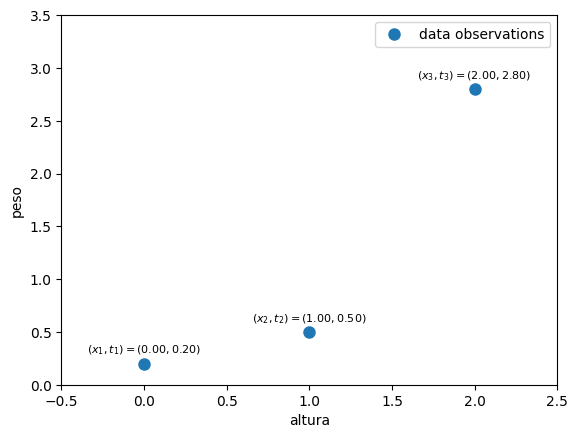

In [48]:
# defining x and t data
x_data =  torch.from_numpy(np.array([0,1,2]).reshape(3,1)).float()
t_data = torch.from_numpy(np.array([0.2,0.5,2.8]).reshape(3,1)).float()

#We plot the data
plt.plot(x_data,t_data,'o', markersize = 8, label = 'data observations')
for i in range(len(x_data)):
    plt.text(x_data[i], t_data[i] + 0.1, f"$(x_{i+1},t_{i+1})=({float(x_data[i]):.2f},{float(t_data[i]):.2f})$", fontsize=8, ha="center")  # Etiqueta sobre el punto
plt.xlabel('altura')
plt.ylabel('peso')
plt.ylim([0,3.5])
plt.xlim([-0.5,2.5])
plt
plt.legend()


**4.2 - 3 Initialization and creation of Computational graph**

Each layer of the network is parameterize by a matrix and a vector of biases, plus the activation function used in that layer.

Thats why we will create an initialization function that:
- Receives the input and output dimension of the problem
- Receives the number of layers
- Receives the neuron per layer
- Receives the activation function to be used

In this example we will assume that all layers will have the same number of neurons and activation function 


In [ ]:
def linear_act_fun(x):
    return x

def initialize_network(num_neurons, num_hidden_layers, hidden_activation_function, output_activation_function, Dx, Dout):

    torch.manual_seed(seed=1)
    np.random.seed(seed=1)

    parameters = []
    dim_in = Dx #input dimension
    dim_out = num_neurons #output dimension

    for l in range(num_hidden_layers+1):
        w = torch.from_numpy(np.random.randn(dim_in, dim_out)).float()
        w.requires_grad = True  
        b = torch.zeros((dim_out,), requires_grad=True, dtype=torch.float)

        if l == num_hidden_layers:

            if output_activation_function == "sigmoid":
                fun_pointer = torch.sigmoid
            elif output_activation_function == "relu":
                fun_pointer = torch.relu
            elif output_activation_function == "linear":
                fun_pointer = linear_act_fun
        elif hidden_activation_function == "tanh":
            fun_pointer = torch.tanh
        else:
            raise ValueError("Invalid activation function")
    
        #add to parameters list
        parameters.append((w, b, fun_pointer))

        #input dimension is the number of neurons in the current layer
        dim_in = num_neurons

        #when we are in the last layer, the output dimension is the target dimension
        if l == num_hidden_layers-1:
            dim_out = Dout

    return parameters


def forward(X, parameters, apply_link_fun): 
    H = X
    
    for l, (W,b,act_fun) in enumerate(parameters):
        Z = torch.mm(H,W) + b
        ## apply activation function on each layer. On last layer check whether the argumetn was specified or not
        H = Z
        if not( not apply_link_fun and l == len(parameters)-1 ) :
            H = act_fun(Z)
    Y = H
    return Y

**4.4-5 Loss Function computation and Gradient descent implementation**

We will use the previous loss functions (absolute, square-error) to implement gradient descent over a neural netword

In [49]:
loss_type = 'sse'

if loss_type not in ["sse","abs"]:
    raise ValueError("Invalid loss type")

## create the plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))
x_range = torch.linspace(-1,3,20).view(20,1)

# Create temporary file for video creation
video_filename = os.path.join(tempfile.gettempdir(), "aux.mp4")

## video writer
writer = imageio.get_writer(video_filename, format="FFMPEG", mode="I", fps=1, codec="libx264")

## Learning algorithm
epochs = 100
lr = 0.1

# 1. Initialize the model
Dx = 1
Dout = 1
num_neurons = 2
num_hidden_layers = 1
hidden_activation_function = 'tanh'
output_activation_function = 'relu'
parameters = initialize_network(num_neurons, num_hidden_layers, hidden_activation_function, output_activation_function, Dx, Dout)

loss_acc = []
for e in range(epochs):
    
    # 2. Forward and loss computation (utilizo las funciones de coste declaradas anteriormente)
    y_data = forward(x_data, parameters, apply_link_fun = True)
    if loss_type == "sse":
        L = loss_funtion_square_torch(t_data, y_data)
        
    elif loss_type == "abs":
        L = loss_funtion_absolute_torch(t_data, y_data)
    
    # 3. Backward
    L.backward()
    loss_acc.append(L.item())
    
    # 5 Parameter update (utilizo gradient descent)
    for w,b,_ in parameters:
        w.data = w.data - lr * w.grad
        b.data = b.data - lr * b.grad
        
    # 6 Zero grad (pongo los gradientes a 0 para que pytorch no los acumule)
    w.grad.zero_()
    b.grad.zero_()
    
    ## Plotting
    ax1.cla()
    ax2.cla()
    
    with torch.no_grad():
        
        ax1.plot(x_data,t_data,'o',label = 'observations')
        ax1.plot(x_range,forward(x_range, parameters,  apply_link_fun = True),label = 'model')
        ax1.set_xlabel('altura')
        ax1.set_ylabel('peso')
        ax1.set_ylim([-3,3.5])
        ax1.set_xlim([-0.5,2.5])
        ax1.legend()
        
        ax2.plot(np.arange(0,e+1),loss_acc)
        ax2.set_xlim([0,epochs])
        ax2.set_xlabel('epochs')
        ax2.set_ylabel('loss')
        ax2.set_title(f"{loss_type}")
    
    ## ========================
    ## save for video generation
    
    ## Cortesía de chatGPT (desde linea siguiente hasta el final de esta celda):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    
    buf.seek(0)
    frame = imageio.imread(buf) 
    writer.append_data(frame)  

writer.close() 
plt.close()

display.display(display.Video(data=video_filename, embed=True))
os.remove(video_filename)

C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\1561088755.py:81: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(buf)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


##### **5.REGRESSION FROM R -> (0,1)**

- 5.1 Plot the data
- 5.2 - 5.4 The network initialization and forward function is exactly the same functions that we used for exercise 4



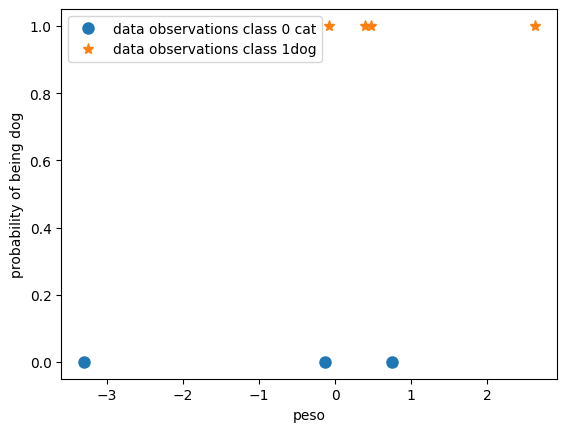

In [51]:
## =============== ##
## Define our data ##
## =============== ##
color_c0 = 'C0'
color_c1 = 'C1'

# input to our model. Represents time in seconds
x_data = torch.from_numpy(np.array([-0.13459237,-3.3015387,0.74481176,2.62434536,0.38824359,0.47182825,-0.07296862]).reshape(7,1)).float()
# outputs associated to each input. Represents cantidad de lluvia in mm^3
t_data = torch.from_numpy(np.array([0,0,0,1,1,1,1]).reshape(7,1)).float()


## display
idx_class0 = t_data == 0
idx_class1 = t_data == 1
fig = plt.figure()
plt.plot(x_data[idx_class0],t_data[idx_class0],'o', color = color_c0, markersize = 8, label = r'data observations class 0 cat')
plt.plot(x_data[idx_class1],t_data[idx_class1],'*', color = color_c1,markersize = 8, label = r'data observations class 1dog')
plt.xlabel('peso')
plt.ylabel('probability of being dog')
plt.legend()

In [52]:
# 5.5 Implement gradient descent 
# in this case we will have to use the sigmoid function in the output layer
# and we will also use the BCE loss fucntion to evaluate the costs

loss_type = 'bce'

if loss_type not in ["bce","brie"]:
    raise ValueError("Invalid loss type")

## create the plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))
x_range = torch.linspace(-4,4,100).view(100,1)

# Create temporary file for video creation
video_filename = os.path.join(tempfile.gettempdir(), "aux.mp4")

## video writer
writer = imageio.get_writer(video_filename, format="FFMPEG", mode="I", fps=1, codec="libx264")

## Learning algorithm
epochs = 100
lr = 0.1

# 1. Initialize the model
Dx = 1
Dout = 1
num_neurons = 2
num_hidden_layers = 1
hidden_activation_function = 'tanh'
output_activation_function = 'sigmoid'
parameters = initialize_network(num_neurons, num_hidden_layers, hidden_activation_function, output_activation_function, Dx, Dout)

loss_acc = []
for e in range(epochs):
    
    # 2. Forward and loss computation (utilizo las funciones de coste declaradas anteriormente)
    y_data = forward(x_data, parameters, apply_link_fun = True)
    if loss_type == "bce":
        L = loss_function_bce(t_data, y_data)
        
    elif loss_type == "brier":
        L = loss_function_brier(t_data, y_data)
    
    # 3. Backward
    L.backward()
    loss_acc.append(L.item())
    
    # 5 Parameter update (utilizo gradient descent)
    for w,b,_ in parameters:
        w.data = w.data - lr * w.grad
        b.data = b.data - lr * b.grad
        
    # 6 Zero grad (pongo los gradientes a 0 para que pytorch no los acumule)
    w.grad.zero_()
    b.grad.zero_()
    
    ## Plotting
    ax1.cla()
    ax2.cla()
    
    with torch.no_grad():
        
        ax1.plot(x_data[idx_class0],t_data[idx_class0],'o', color = color_c0, markersize = 8, label = r'data observations class 0 cat')
        ax1.plot(x_data[idx_class1],t_data[idx_class1],'*', color = color_c1,markersize = 8, label = r'data observations class 1dog')
        ax1.plot(x_range, forward(x_range, parameters, apply_link_fun = True), label = 'model')
        ax1.set_xlabel('peso')
        ax1.set_ylabel('probability of being dog')
        ax1.set_ylim([-0.5,1.5])
        ax1.set_xlim([-4,4])
        ax1.legend()
        
        ax2.plot(np.arange(0,e+1),loss_acc)
        ax2.set_xlim([0,epochs])
        ax2.set_xlabel('epochs')
        ax2.set_ylabel('loss')
        ax2.set_title(f"{loss_type}")
    
    ## ========================
    ## save for video generation
    
    ## Cortesía de chatGPT (desde linea siguiente hasta el final de esta celda):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    
    buf.seek(0)
    frame = imageio.imread(buf) 
    writer.append_data(frame)  

writer.close() 
plt.close()

display.display(display.Video(data=video_filename, embed=True))
os.remove(video_filename)

C:\Users\pablo\AppData\Local\Temp\ipykernel_24016\1722099368.py:86: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frame = imageio.imread(buf)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


#### **6. REGRESSION FROM R^2 -> (0,1)**
- 6.1 Plotting the data
- 6.2-4 Defining the new network with two hidden layers
- 6.5 Implementing the model


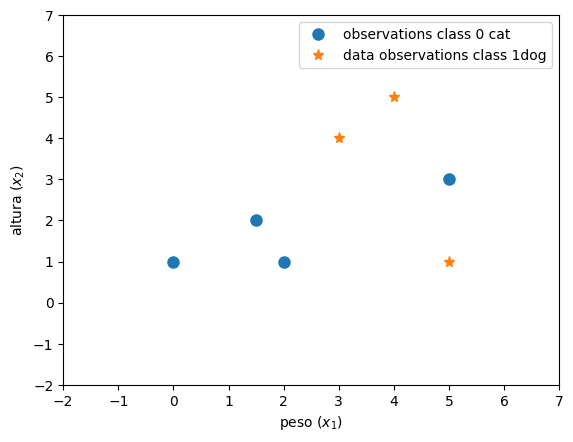

In [53]:
## =============== ##
## Define our data ##
## =============== ##
color_c0 = 'C0'
color_c1 = 'C1'

# input to our model. Represents time in seconds
x_data = torch.from_numpy( 
                          np.array([[0,1],
                                   [1.5,2.0],
                                   [2,1],
                                   [5,3],
                                   [3,4],
                                   [4,5],
                                   [5,1]]).reshape(7,2)
                         ).float()

# outputs associated to each input. Represents cantidad de lluvia in mm^3
t_data =  torch.from_numpy(np.array([0,0,0,0,1,1,1]).reshape(7,1)).float()

## display
fig = plt.figure()
idx_class0 = torch.squeeze(t_data == 0)
idx_class1 = torch.squeeze(t_data == 1)
plt.plot(x_data[idx_class0][:,0],x_data[idx_class0][:,1],'o', color = color_c0, markersize = 8, label = r'observations class 0 cat')
plt.plot(x_data[idx_class1][:,0],x_data[idx_class1][:,1],'*', color = color_c1,markersize = 8, label = r'data observations class 1dog')
plt.xlabel('peso ($x_1$)')
plt.ylabel('altura ($x_2$)')
plt.xlim([-2,7])
plt.ylim([-2,7])
plt.legend()

In [ ]:
# 6.2 New initiaization of the network

# the number of neurons is the number of neurons per layer
# we will need to specify the input and output dimension

def initialize_network(num_neurons, num_hidden_layers, hidden_activation_function, output_activation_function, Dx, Dout):
    torch.manual_seed(seed=1)
    np.random.seed(seed=1)

    parameters = []
    dim_in = Dx
    dim_out = num_neurons
    
    for l in range(num_hidden_layers+1):
        w = torch.from_numpy(np.random.randn(dim_in,dim_out)).float()
        w.requires_grad = True
        b = torch.zeros((dim_out,), requires_grad = True, dtype = torch.float)
        
        if l == num_hidden_layers:
            
            if output_activation_function == 'sigmoid':
                fun_pointer = torch.sigmoid
            elif output_activation_function == 'relu':
                fun_pointer = torch.relu
            elif output_activation_function == 'linear':
                fun_pointer = linear_act_fun
                
        elif hidden_activation_function == 'tanh':
            fun_pointer = torch.tanh
            
        elif hidden_activation_function == 'relu':
            fun_pointer = torch.relu
        else:
            raise ValueError("Activation function can only be tanh")

        ## add to parameter list
        parameters.append((w,b,fun_pointer))
    
        ## then input dimension is num_neurons
        dim_in = num_neurons
        
        ## when we are in the last layer, the output dimension is the target dimension.
        if l == num_hidden_layers-1:
            dim_out = Dout
    
    return parameters


In [ ]:
# 6.5 Initializing network

